<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
path =r"C:\Users\21650\Downloads\survey_data.csv"
df = pd.read_csv(path)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [2]:
## Write your code here
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 114 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    ResponseId                      int64  
 1    MainBranch                      object 
 2    Age                             object 
 3    Employment                      object 
 4    RemoteWork                      object 
 5    Check                           object 
 6    CodingActivities                object 
 7    EdLevel                         object 
 8    LearnCode                       object 
 9    LearnCodeOnline                 object 
 10   TechDoc                         object 
 11   YearsCode                       object 
 12   YearsCodePro                    object 
 13   DevType                         object 
 14   OrgSize                         object 
 15   PurchaseInfluence               object 
 16   BuyNewTool                      object 
 17   BuildvsBuy

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [3]:
## Write your code here
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [4]:
col_names=[]
missing_amount=[]
for col in df.columns.values:
    amount=round((df[col].isna().sum()/len(df))*100,2)
    col_names.append(col)
    missing_amount.append(amount)
df_missing=pd.DataFrame({"Column_Name":col_names,"Missing_Amount_Percentage":missing_amount})
df_missing=df_missing.sort_values(by="Missing_Amount_Percentage",ascending=False,ignore_index=True)
df_missing


#Or just simply:
#for col in df.columns.values:
#    print("column:",col,"\n","Missing Data:",round((df[col].isna().sum()/len(df))*100,2),"\n\n")

,Column_Name,Missing_Amount_Percentage
0,AINextMuch less integrated,98.25
1,AINextLess integrated,96.40
2,AINextNo change,80.90
3,AINextMuch more integrated,79.46
4,EmbeddedAdmired,74.43
...,...,...
109,MainBranch,0.00
110,Age,0.00
111,Employment,0.00
112,Check,0.00


In [5]:
for col in df_missing["Column_Name"]:
    if df_missing.loc[df_missing["Column_Name"]==col,"Missing_Amount_Percentage"].iloc[0]>=70:
        df.drop(col,axis=1,inplace=True)
    else:
        if pd.api.types.is_numeric_dtype(df[col]):
            if -0.5<df[col].dropna().skew()<0.5:
                df[col].fillna(df[col].mean(),inplace=True)
            else:
                df[col].fillna(df[col].median(),inplace=True)
        else:
            df[col].fillna(df[col].value_counts().idxmax(),inplace=True)


C:\Users\21650\AppData\Local\Temp\ipykernel_1848\4261754861.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].value_counts().idxmax(),inplace=True)
C:\Users\21650\AppData\Local\Temp\ipykernel_1848\4261754861.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [8]:
## Write your code here
pd.set_option("display.max_rows",10)
cols=["Employment","JobSat","YearsCodePro"]
for col in cols:
    print(df[col].value_counts().reset_index().head())

                                          Employment  count
0                                Employed, full-time  39041
1  Independent contractor, freelancer, or self-em...   4846
2                                 Student, full-time   4709
3  Employed, full-time;Independent contractor, fr...   3557
4                 Not employed, but looking for work   2341
   JobSat  count
0     7.0  42690
1     8.0   7509
2     6.0   3751
3     9.0   3626
4    10.0   2251
  YearsCodePro  count
0            2  17995
1            3   4093
2            5   3526
3           10   3251
4            4   3215


### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


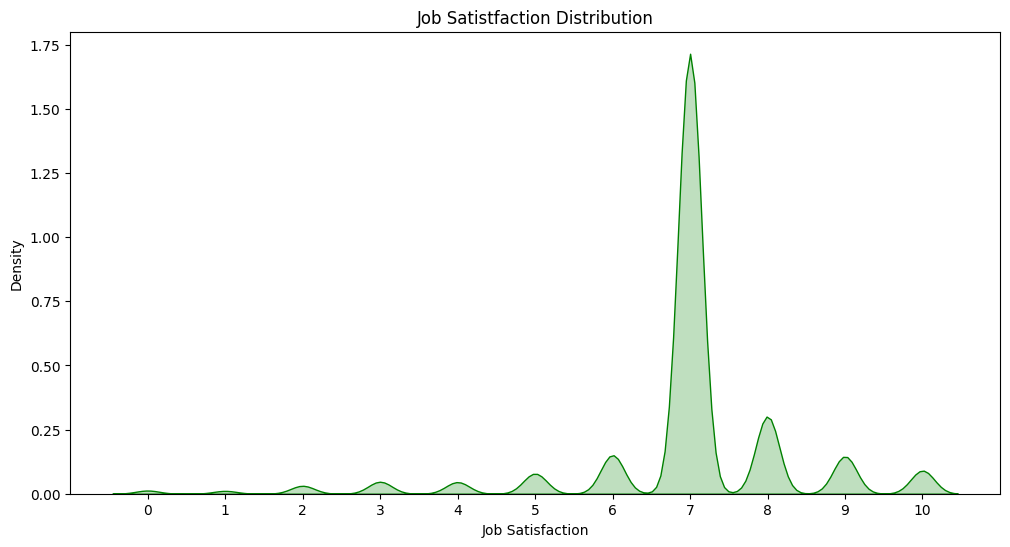

In [9]:
## Write your code here
plt.figure(figsize=(12,6))
sns.kdeplot(df,x="JobSat",fill=True,color="green")
plt.xlabel("Job Satisfaction")
plt.title("Job Satistfaction Distribution")
plt.xticks(list(range(0,11)))
plt.show()

From this distribution plot we can see the values are mostly centered around a job satisfaction rating of 7 followed by 8, reflecting the attractiveness of IT-related occupations.

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


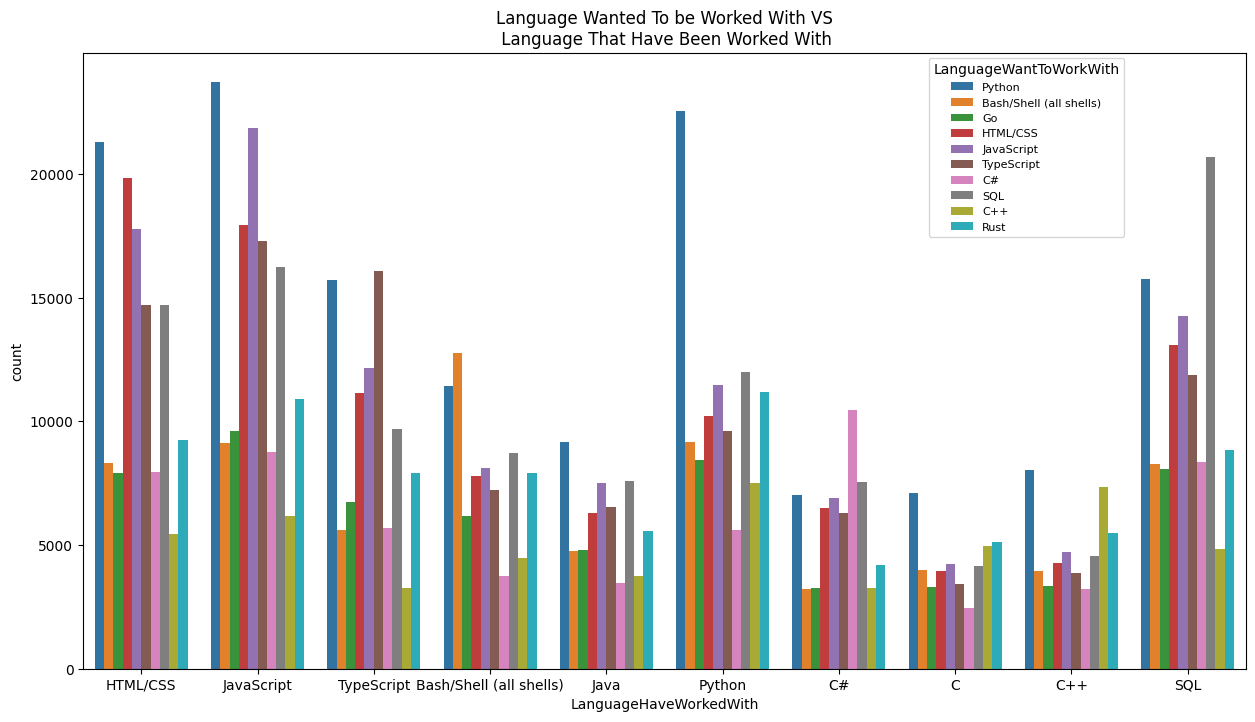

In [10]:
## Write your code here
df1=df.copy()
cols=["LanguageHaveWorkedWith","LanguageWantToWorkWith"]
for col in cols:
    df1[col]=df[col].str.split(";")
    df1=df1.explode(col)
    df1[col]=df1[col].str.strip()

top_langs1=df1["LanguageHaveWorkedWith"].value_counts().head(10).index
top_langs2=df1["LanguageWantToWorkWith"].value_counts().head(10).index
df_filtered=df1[(df1["LanguageHaveWorkedWith"].isin(top_langs1))&(df1["LanguageWantToWorkWith"].isin(top_langs2))]
plt.figure(figsize=(15,8))
sns.countplot(data=df_filtered,x="LanguageHaveWorkedWith",hue="LanguageWantToWorkWith")
plt.legend(bbox_to_anchor =[0.9,1],fontsize=8,title="LanguageWantToWorkWith")
plt.title("Language Wanted To be Worked With VS\n Language That Have Been Worked With")
plt.show()

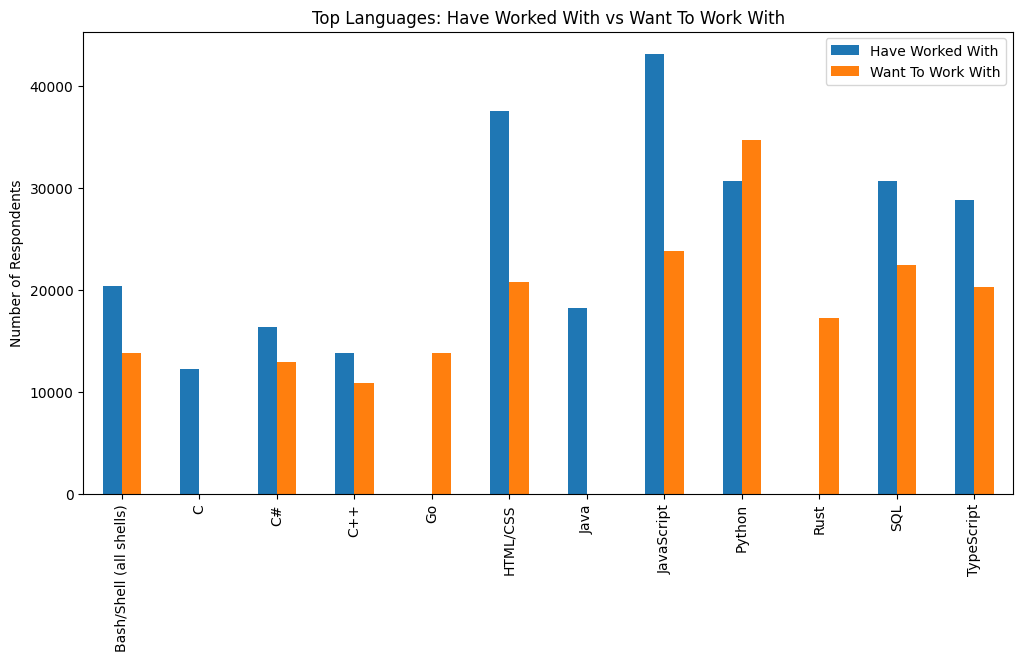

In [11]:
# Method 2:
df_have = df.copy()
df_have["LanguageHaveWorkedWith"] = df_have["LanguageHaveWorkedWith"].str.split(";")
df_have = df_have.explode("LanguageHaveWorkedWith")
df_have["LanguageHaveWorkedWith"] = df_have["LanguageHaveWorkedWith"].str.strip()

df_want = df.copy()
df_want["LanguageWantToWorkWith"] = df_want["LanguageWantToWorkWith"].str.split(";")
df_want = df_want.explode("LanguageWantToWorkWith")
df_want["LanguageWantToWorkWith"] = df_want["LanguageWantToWorkWith"].str.strip()

top_have = df_have["LanguageHaveWorkedWith"].value_counts().head(10)
top_want = df_want["LanguageWantToWorkWith"].value_counts().head(10)

import pandas as pd

lang_counts = pd.DataFrame({
    "Have Worked With": top_have,
    "Want To Work With": top_want
}).fillna(0)

lang_counts.plot(kind="bar", figsize=(12,6))
plt.title("Top Languages: Have Worked With vs Want To Work With")
plt.ylabel("Number of Respondents")
plt.show()


### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


C:\Users\21650\AppData\Local\Temp\ipykernel_1848\3677313837.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtered["Country"].replace(country_map,inplace=True)
C:\Users\21650\AppData\Local\Temp\ipykernel_1848\3677313837.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Country"].replace(country_map,inplace=True)
C:\User

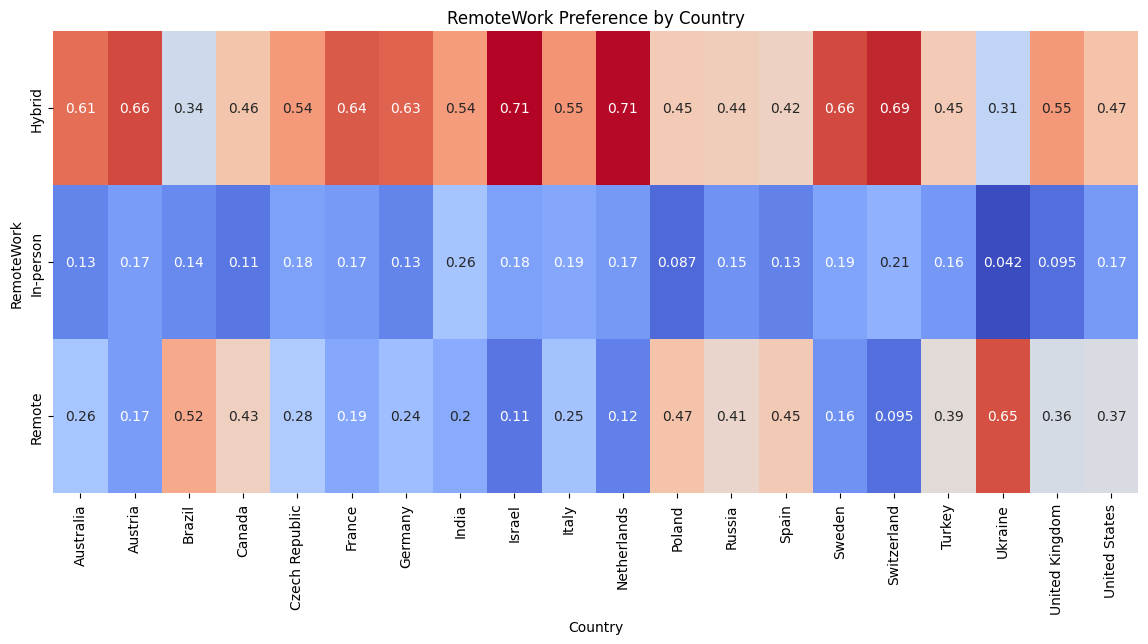

In [12]:
## Write your code here


top_countries=df["Country"].value_counts().head(20).index
df_filtered=df[df["Country"].isin(top_countries)]
country_map={"United Kingdom of Great Britain and Northern Ireland":"United Kingdom",
             "Russian Federation":"Russia","United States of America":"United States"}
df_filtered["Country"].replace(country_map,inplace=True)
df_filtered["RemoteWork"].replace({"Hybrid (some remote, some in-person)":"Hybrid"},inplace=True)

crosstab=pd.crosstab(df_filtered["RemoteWork"],df_filtered["Country"],normalize='columns')

plt.figure(figsize=(14,6))
sns.heatmap(crosstab,cmap="coolwarm",cbar=False,annot=True)
plt.title("RemoteWork Preference by Country")
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


Coefficient of correlation between YearsCodePro and JobSat= 0.0658

p-value= 1.2348452622706877e-63


C:\Users\21650\AppData\Local\Temp\ipykernel_1848\2917628134.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["YearsCodePro"].replace(years_map,inplace=True)


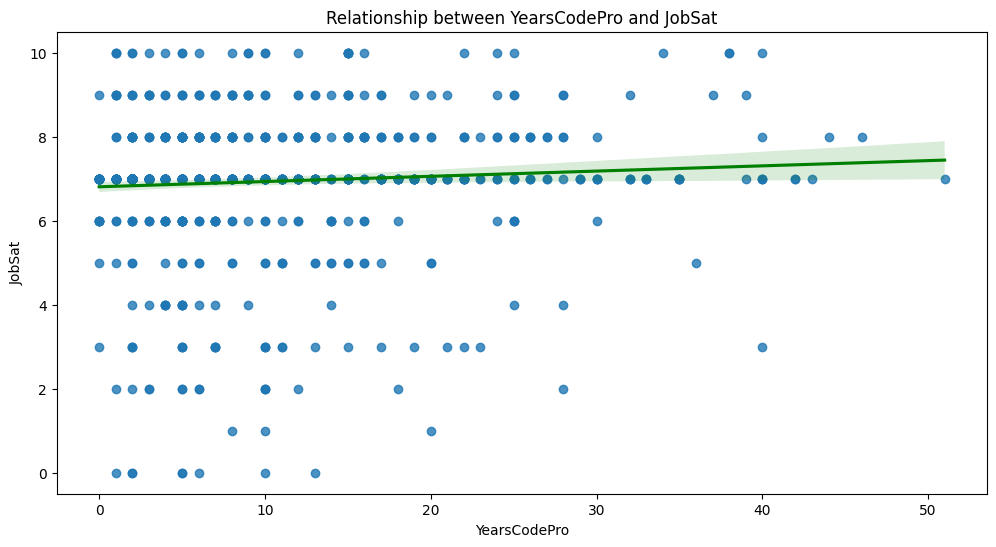

In [15]:
## Write your code here
from scipy.stats import pearsonr

years_map={"Less than 1 year":"0","More than 50 years":"51"}
df["YearsCodePro"].replace(years_map,inplace=True)
df["YearsCodePro"]=pd.to_numeric(df["YearsCodePro"],errors="coerce")

print("Coefficient of correlation between YearsCodePro and JobSat=",round(pearsonr(df["YearsCodePro"],df["JobSat"])[0],4))
print("\np-value=",pearsonr(df["YearsCodePro"],df["JobSat"])[1])

plt.figure(figsize=(12,6))
sns.regplot(df.sample(1000),x="YearsCodePro",y="JobSat",line_kws={"color":"green"})
plt.title("Relationship between YearsCodePro and JobSat")
plt.show()

=> No significant correlation was found between YearsCodePro and JobSat.

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


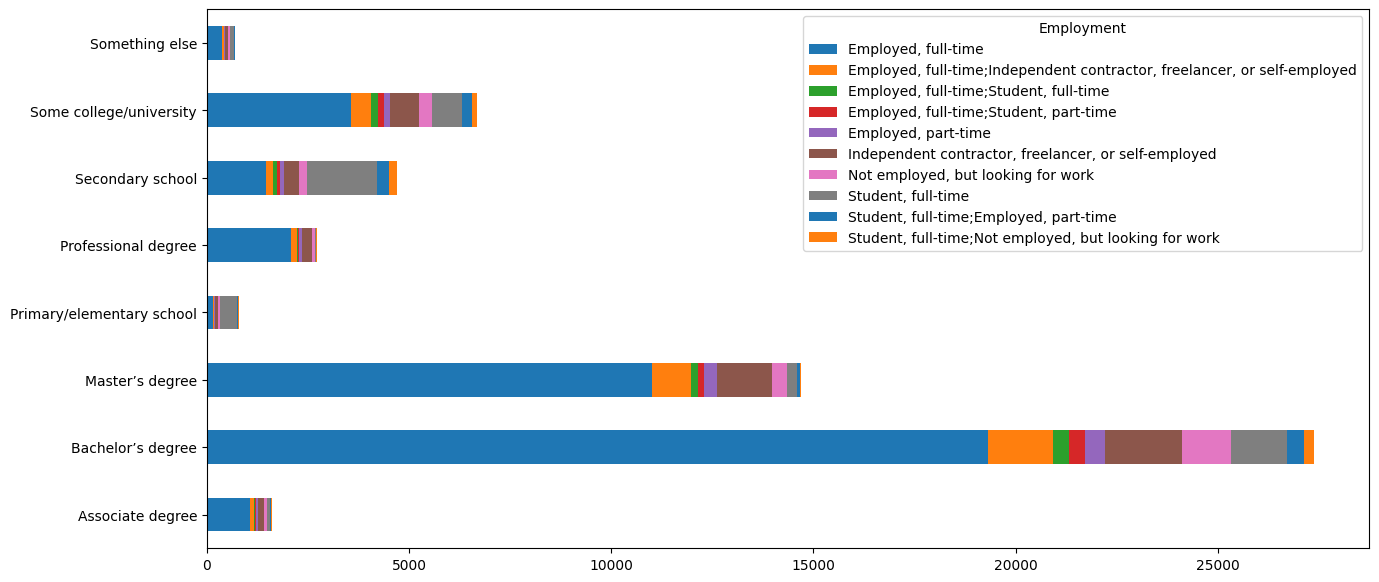

In [16]:
top_empl = df["Employment"].value_counts().head(10).index
df_filtered1 = df[df["Employment"].isin(top_empl)]

crosstab1 = pd.crosstab(df_filtered1["EdLevel"], df_filtered1["Employment"])
crosstab1.index=["Associate degree","Bachelor’s degree","Master’s degree","Primary/elementary school","Professional degree","Secondary school","Some college/university","Something else"]
colors = sns.color_palette("tab10", n_colors=len(crosstab1.index))

ax = crosstab1.plot(kind="barh", stacked=True,figsize=(15,7),color=colors)


plt.show()


### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [105]:
## Write your code here
df.to_csv(r"C:\Users\21650\Downloads\cleaned_df.csv")

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
